## Load dataset

(70000, 28, 28)
(70000,)
0


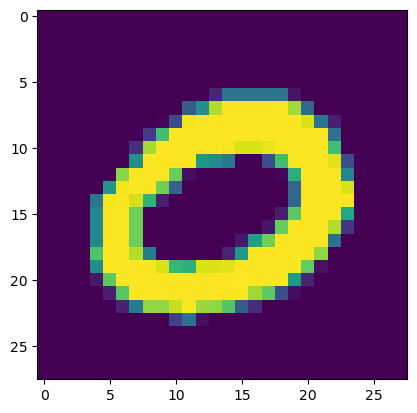

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import struct 

IMGS_SIZE = 28

def read_images(filepath):
    with open(filepath, 'rb') as f:
        magic, num, rows, cols = struct.unpack(">IIII", f.read(16))
        images = np.frombuffer(f.read(), dtype=np.uint8).reshape(num, IMGS_SIZE, IMGS_SIZE)
    return images

def read_labels(filepath):
    with open(filepath, 'rb') as f:
        magic, num = struct.unpack(">II", f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels

imgs_60k = read_images("./Datasets/train-images.idx3-ubyte")
imgs_10k = read_images("./Datasets/t10k-images.idx3-ubyte")

labels_60k = read_labels("./Datasets/train-labels.idx1-ubyte")
labels_10k = read_labels("./Datasets/t10k-labels.idx1-ubyte")

imgs = np.vstack([imgs_60k, imgs_10k])
labels = np.hstack([labels_60k, labels_10k])

print(imgs.shape)
print(labels.shape)

print(labels[6001])
plt.imshow(imgs[6001])

## Split into train, validation and test

In [2]:
from sklearn.model_selection import train_test_split

def train_test_valid_split(imgs, labels, valid_ratio, test_ratio):
    
    train_ratio = 1.0 - (valid_ratio + test_ratio)

    train_test_imgs, val_imgs, train_test_labels, val_labels = train_test_split(imgs, labels, test_size=valid_ratio, random_state=9)
    train_imgs, test_imgs, train_labels, test_labels = train_test_split(train_test_imgs, train_test_labels, test_size=test_ratio / (train_ratio + test_ratio), random_state=9)

    return (train_imgs, train_labels), (val_imgs, val_labels), (test_imgs, test_labels)

## Test KNN parameters

In [12]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from random import sample
import tqdm

def test_knn_params(k, metric, train, valid, scale=True, sample_size=1.0):

    train_imgs, train_labels = train
    val_imgs, val_labels = valid
    img_size = train_imgs[0].shape[0]

    # Sample a subset of the training and validation data
    num_samples = int(len(train_imgs) * sample_size)
    idxs = sample(range(len(train_imgs)), k=num_samples)
    train_imgs = train_imgs[idxs].reshape((-1, img_size*img_size))
    train_labels = train_labels[idxs]

    num_samples = int(len(val_imgs) * sample_size)
    idxs = sample(range(len(val_imgs)), k=num_samples)
    val_imgs = val_imgs[idxs].reshape((-1, img_size*img_size))
    val_labels = val_labels[idxs]

    # Normalize between 0 and 1
    if scale:
        scaler = StandardScaler()
        train_imgs = scaler.fit_transform(train_imgs)
        val_imgs = scaler.transform(val_imgs)

    knn = KNeighborsClassifier(n_neighbors=k, metric=metric)
    knn.fit(train_imgs, train_labels)
    pred_labels = knn.predict(val_imgs)

    return accuracy_score(val_labels, pred_labels)

def train_knn(train, valid, k_values, metrics, sample_size=1.0):

    error_scores = {}
    for metric in metrics: 
        error_scores[metric] = []
        for k in tqdm.tqdm(k_values):
            accuracy = test_knn_params(k, metric, train, valid, sample_size=sample_size)
            error_scores[metric].append(1 - accuracy)

        print(f"Metric: {metric}, K values: {list(k_values)}, Error scores: {error_scores[metric]}")

    return error_scores


## Find the best K value, metric and split for this dataset

100%|██████████| 10/10 [00:33<00:00,  3.35s/it]


Metric: cityblock, K values: [1, 3, 5, 7, 9, 11, 13, 15, 17, 19], Error scores: [0.06642857142857139, 0.06142857142857139, 0.06571428571428573, 0.06571428571428573, 0.059285714285714275, 0.07999999999999996, 0.06785714285714284, 0.0764285714285714, 0.08214285714285718, 0.08214285714285718]


100%|██████████| 10/10 [02:45<00:00, 16.60s/it]


Metric: cosine, K values: [1, 3, 5, 7, 9, 11, 13, 15, 17, 19], Error scores: [0.08714285714285719, 0.08285714285714285, 0.07357142857142862, 0.08714285714285719, 0.0764285714285714, 0.09285714285714286, 0.0892857142857143, 0.09571428571428575, 0.08857142857142852, 0.09571428571428575]


100%|██████████| 10/10 [00:59<00:00,  5.98s/it]


...

100%|██████████| 10/10 [00:39<00:00,  3.91s/it]


Metric: manhattan, K values: [1, 3, 5, 7, 9, 11, 13, 15, 17, 19], Error scores: [0.0803571428571429, 0.07107142857142856, 0.06964285714285712, 0.0753571428571429, 0.06857142857142862, 0.08999999999999997, 0.08107142857142857, 0.0903571428571428, 0.08964285714285714, 0.08678571428571424]


100%|██████████| 10/10 [13:30<00:00, 81.07s/it]
/tmp/ipykernel_59409/950286222.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[i].legend()


Metric: nan_euclidean, K values: [1, 3, 5, 7, 9, 11, 13, 15, 17, 19], Error scores: [0.08892857142857147, 0.08785714285714286, 0.08964285714285714, 0.08750000000000002, 0.08642857142857141, 0.10250000000000004, 0.09214285714285719, 0.1071428571428571, 0.11285714285714288, 0.10857142857142854]
Errors for split ratios (0.6, 0.2, 0.2): {'cityblock': [0.07571428571428573, 0.0714285714285714, 0.07392857142857145, 0.08607142857142858, 0.08178571428571424, 0.09071428571428575, 0.09250000000000003, 0.08857142857142852, 0.08714285714285719, 0.10392857142857148], 'cosine': [0.09750000000000003, 0.09214285714285719, 0.08999999999999997, 0.10357142857142854, 0.10535714285714282, 0.09571428571428575, 0.10107142857142859, 0.1060714285714286, 0.10821428571428571, 0.1060714285714286], 'euclidean': [0.08571428571428574, 0.1060714285714286, 0.09071428571428575, 0.09357142857142853, 0.09750000000000003, 0.08999999999999997, 0.09999999999999998, 0.09928571428571431, 0.10142857142857142, 0.1146428571428571

<Figure size 1200x800 with 0 Axes>

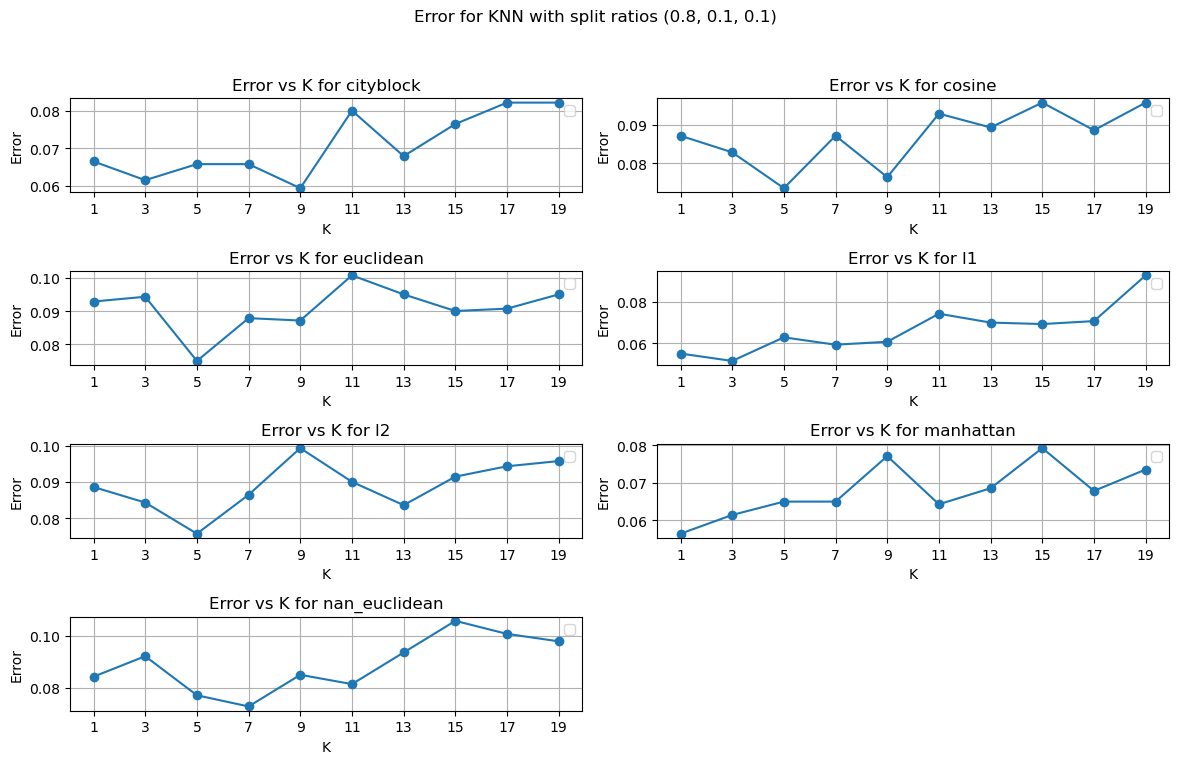

<Figure size 1200x800 with 0 Axes>

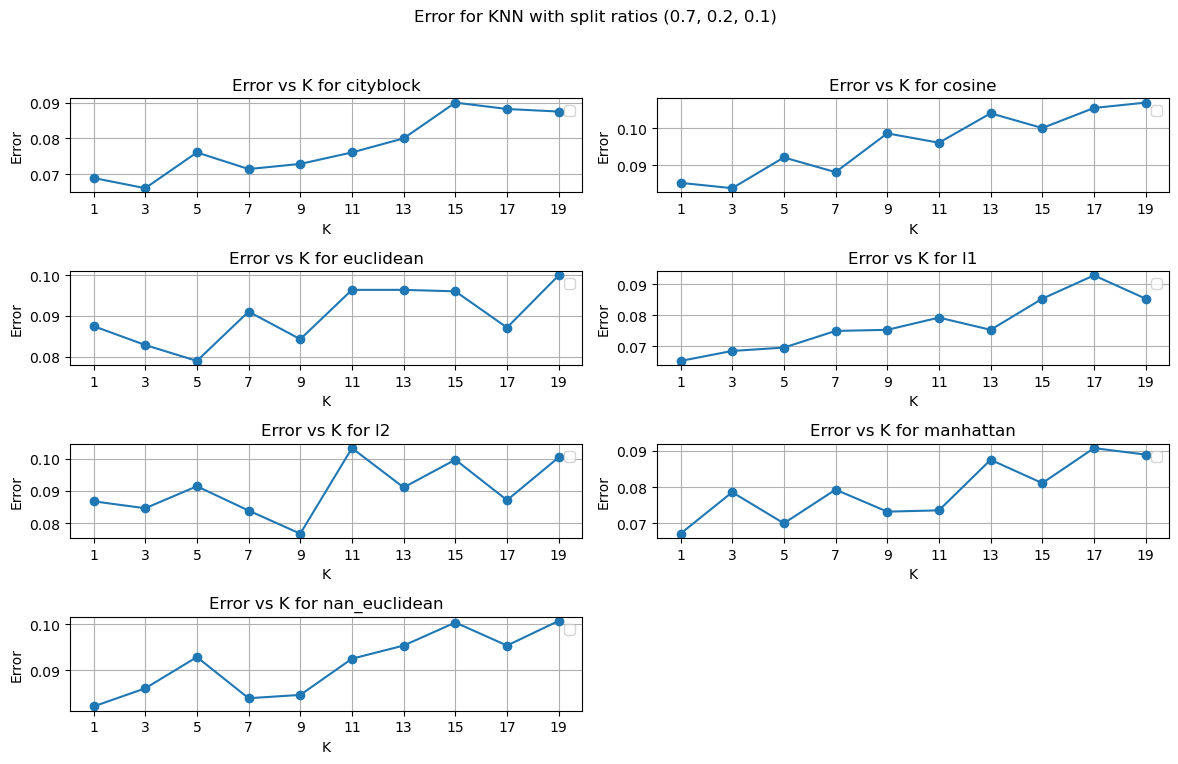

<Figure size 1200x800 with 0 Axes>

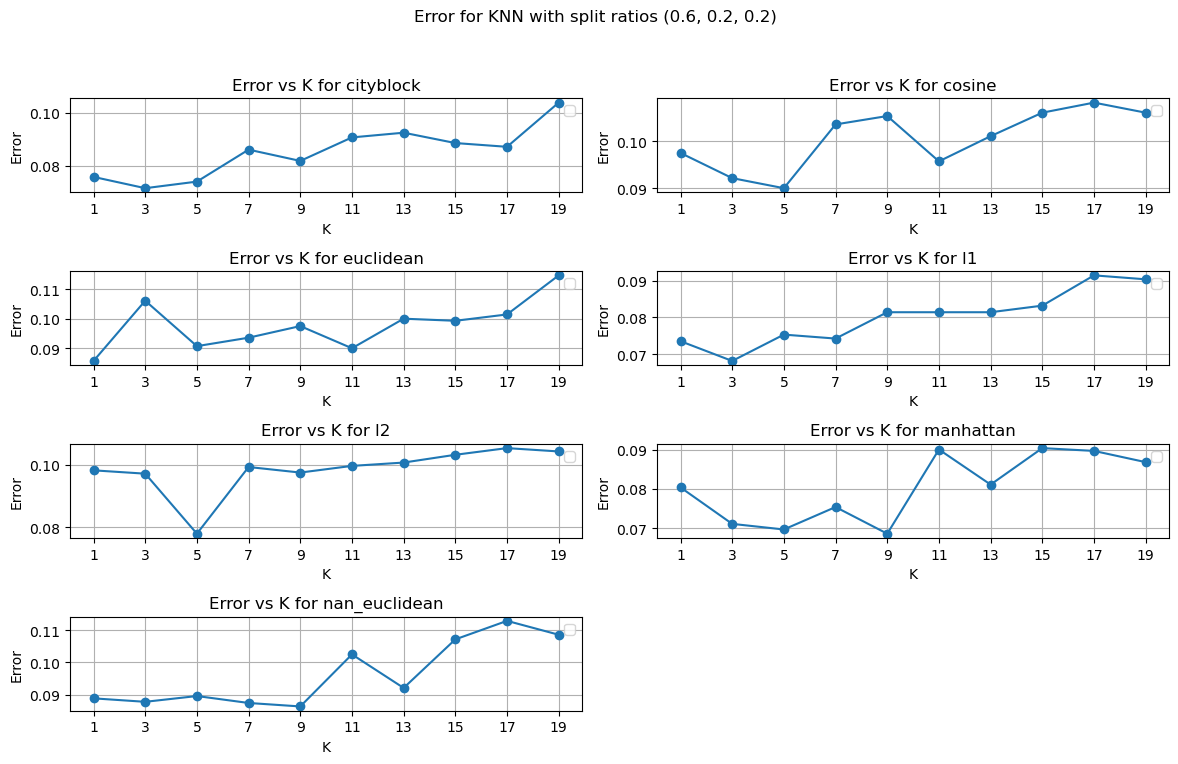

In [14]:
def plot(errors, title):
    plt.figure(figsize=(12, 8))
    fig, ax = plt.subplots(4, 2, figsize=(12, 8))
    ax = ax.flatten()
    for i, (metric, error) in enumerate(errors.items()):
        ax[i].plot(list(K_VALUES), error, marker='o')
        ax[i].set_title(f'Error vs K for {metric}')
        ax[i].set_xlabel('K')
        ax[i].set_xticks(list(K_VALUES))
        ax[i].set_ylabel('Error')
        ax[i].grid(True)
    fig.suptitle(title)
    fig.tight_layout(rect=[0, 0.03, 1, 0.95])
    fig.delaxes(ax[-1])  # Remove the last empty subplot
    
    
K_VALUES = [k for k in range(1, 21) if k % 2 == 1]  
METRICS = ['cityblock', 'cosine', 'euclidean', 'l1', 'l2', 'manhattan', 'nan_euclidean']
DATASET_RATIOS = [
    (0.8, 0.1, 0.1), 
    (0.7, 0.2, 0.1),
    (0.6, 0.2, 0.2)
]
SAMPLE = 0.2 # Downsample the base for training to increase speed

for ratios in DATASET_RATIOS:
    train, valid, _ = train_test_valid_split(imgs, labels, ratios[1], ratios[2])
    errors = train_knn(train, valid, K_VALUES, METRICS, SAMPLE)
    print(f"Errors for split ratios {ratios}: {errors}")
    plot(errors, f"Error for KNN with split ratios {ratios}")

## Using the best parameters to test
* Split = 80/10/10
* Metric = Cityblock
* K = 9

In [4]:
from sklearn.metrics import accuracy_score, classification_report

train, _, test = train_test_valid_split(imgs, labels, 0.1, 0.1)

scaler = StandardScaler()
train_imgs, train_labels = train
test_imgs, test_labels = test
train_imgs = scaler.fit_transform(train_imgs.reshape((-1, IMGS_SIZE * IMGS_SIZE)))
test_imgs = scaler.transform(test_imgs.reshape((-1, IMGS_SIZE * IMGS_SIZE)))

knn = KNeighborsClassifier(n_neighbors=9, metric='cityblock')
knn.fit(train_imgs, train_labels)
pred_labels = knn.predict(test_imgs)

print(f"Accuracy: {accuracy_score(test_labels, pred_labels)}")
print("Classification Report:")
print(classification_report(test_labels, pred_labels, digits=4))


Accuracy: 0.9564347950292815
Classification Report:
              precision    recall  f1-score   support

           0     0.9686    0.9941    0.9812       683
           1     0.9104    0.9922    0.9495       768
           2     0.9781    0.9318    0.9544       718
           3     0.9486    0.9574    0.9530       752
           4     0.9639    0.9712    0.9675       659
           5     0.9621    0.9369    0.9493       650
           6     0.9708    0.9823    0.9765       678
           7     0.9453    0.9555    0.9503       741
           8     0.9856    0.9029    0.9424       680
           9     0.9459    0.9360    0.9409       672

    accuracy                         0.9564      7001
   macro avg     0.9579    0.9560    0.9565      7001
weighted avg     0.9572    0.9564    0.9563      7001



## Show results on a few examples

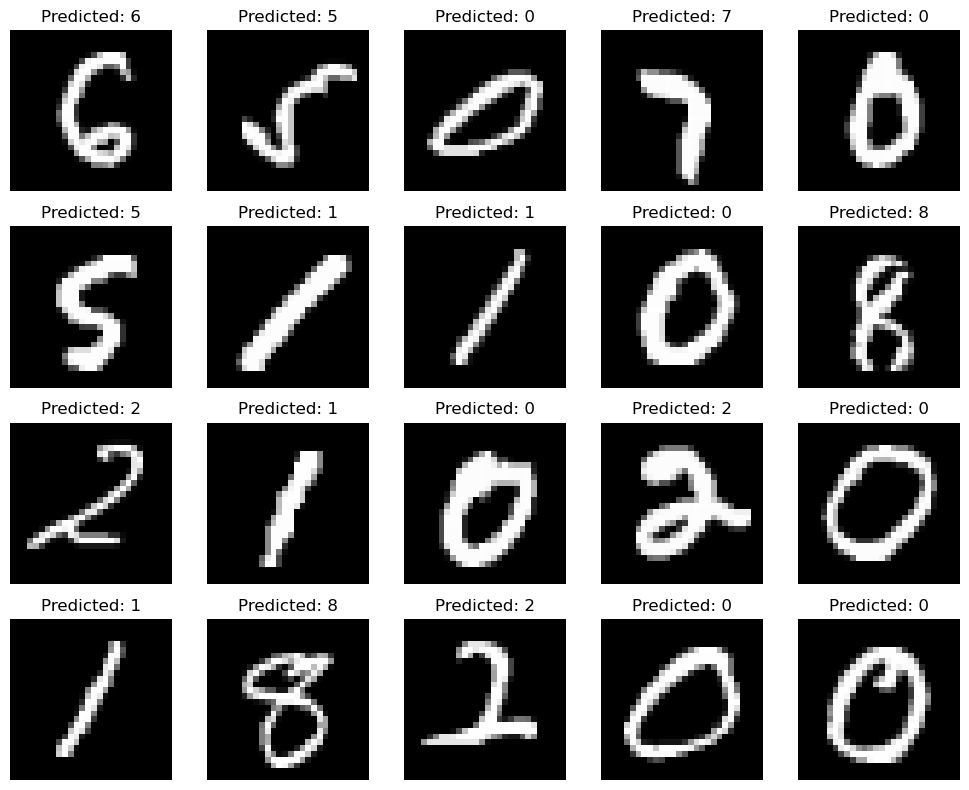

In [5]:
EXAMPLES_NUM = 20

sample_test_imgs = sample(list(test_imgs), k=EXAMPLES_NUM)

fig, axes = plt.subplots(4, 5, figsize=(10, 8))

for ax, img in zip(axes.flatten(), sample_test_imgs):
    
    pred_label = knn.predict(img.reshape(1, -1))[0]
    rescaled_img = img * scaler.scale_ + scaler.mean_  # Rescale back to original pixel values
    
    ax.imshow(rescaled_img.reshape(IMGS_SIZE, IMGS_SIZE), cmap='gray')
    ax.set_title(f'Predicted: {pred_label}')
    ax.axis('off')

plt.tight_layout()
plt.show()